# Validation of gravity correction

In [ ]:
import sys
sys.path.append('/Users/igavier/Documents/GitHub/Neuromorphic-IMU/python-pipeline/')
from modules import *
from wavelets import *

import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt
import seaborn as sn

import argparse
import tqdm

from scipy.interpolate import interp1d
import csv

In [ ]:
subject_ID = 1
sampleFreq = 64

In [ ]:
timeOffsets = {1: 10.9, 2: 2.1, 3: 3.4, 4: 3.0, 5: 12.4, 6: 4.45, 7:-26.95, 8:19.5, 10: 8.4, 11: 7.4,
            12: 24.4, 13: 11.5, 14: 39.5, 15: 8.3, 16: 14.2, 17: 2.3, 18: 6.3, 19: 7.6, 20: 3.0}

# Read Shimmer files
rows = []
with open(f'/Users/igavier/Documents/PhD-nonsync/Subject{subject_ID:03d}/annotation/Subject{subject_ID:03d}_left_acc_gyr.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=",")
    for _ in range(1): next(reader, _)
    for row in reader: rows += [row]

# Extract Shimmer data
AccLeftAll = np.array(rows, dtype=float)
timeLeftAcc = AccLeftAll[:,0]
leftAcc = AccLeftAll[:,1:4]
dTAcc = 1 / (1 / np.diff(timeLeftAcc)).mean().round()

func = lambda x: interp1d(timeLeftAcc[~np.isnan(x)], x[~np.isnan(x)], fill_value='extrapolate')(np.arange(len(x) * dTAcc * sampleFreq) / sampleFreq)
leftAcc = np.apply_along_axis(func, 0, leftAcc)
timeLeftAcc = func(timeLeftAcc)

# Read MoCap files
mocapAll = pd.read_csv(f'/Users/igavier/Documents/PhD-nonsync/Subject{subject_ID:03d}/mocap/Subject{subject_ID:03d}.tsv', header=11, sep='\t', index_col=0)
mocapAll = mocapAll[['Time'] + [f'{s}_{m} {a}' for s in ['left','right'] for m in ['finger','wrist'] for a in ['X','Y','Z']]]

# Extract MoCap data
timeMoCap = (mocapAll['Time'] - timeOffsets[subject_ID]).to_numpy()
leftWristMoCap = (mocapAll[[f'left_wrist {a}' for a in ['X','Y','Z']]] / 1000).to_numpy()
dTMoCap = np.diff(timeMoCap).mean()

b, a = signal.butter(3, 12 * 2 * dTMoCap, 'lowpass')
func = lambda x: interp1d(timeMoCap[~np.isnan(x)], x[~np.isnan(x)], fill_value='extrapolate')(np.arange(len(x) * dTMoCap * sampleFreq) / sampleFreq)
leftMoCap = signal.filtfilt(b, a, np.apply_along_axis(func, 0, leftWristMoCap), axis=0)
timeMoCap = func(timeMoCap)
leftVelMoCap = signal.filtfilt(b, a, np.gradient(leftMoCap, timeMoCap, axis=0), axis=0)
leftAccMoCap = signal.filtfilt(b, a, np.gradient(leftVelMoCap, timeMoCap, axis=0), axis=0)

### Naive High Pass Filter

In [5]:
b, a = signal.butter(3, 0.2 * 2 / sampleFreq, 'highpass')
leftGAccHPF = signal.filtfilt(b, a, leftAcc, axis=0)

### Our Gravity Correction

In [55]:
G = np.array([0,0,1])

def rotateAndRemoveGravity(accL, fS, f0=2, N=2):
    # Get coefficients
    b, a = butter(N, f0 / (fS / 2))

    # Get local gravity
    gravL = signal.filtfilt(b, a, accL, axis=0)
    gravLnorm = np.linalg.norm(gravL, axis=1)

    # Get rotation axis and angle
    k = np.cross(gravL, G, axisa=1)
    k /= np.linalg.norm(k, axis=1)[:,None]
    theta = np.arccos(np.dot(gravL, np.array([0,0,1])) / gravLnorm)
    theta = theta[:,None]

    # Rotate using Rodrigues and remove gravity
    accG = (accL * np.cos(theta) + np.cross(k, accL, axisa=1, axisb=1) * np.sin(theta)
            + k * (k * accL).sum(1)[:,None] * (1 - np.cos(theta)))
    b, a = signal.butter(5, 1, 'highpass', fs=fS)
    accG = signal.filtfilt(b, a, accG, axis=0)
    
    return accG

leftGAccGC = rotateAndRemoveGravity(leftAcc, sampleFreq, f0=1)

### Xylo Gravity Correction

In [51]:
'''
Before running this, make sure to install the rockpool package:

# - General installation and imports
import sys
!{sys.executable} -m pip install --quiet matplotlib rich "rockpool[xylo, torch]"

# - Import numpy
import numpy as np

# - Configure matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 300

# - Display images
from IPython.display import Image

import warnings
warnings.filterwarnings('ignore')

# - Nice printing
from rich import print
'''

from rockpool.devices.xylo.syns63300.imuif import RotationRemoval
from rockpool.devices.xylo.syns63300 import Quantizer
from scipy import signal

G = np.array([1,0,0])

def XyloRotateAndRemoveGravity(accL, fS):
    # Define Xylo modules
    quantizer = Quantizer(scale=0.49)
    rot_removal = RotationRemoval()

    # Quantize and remove rotation
    accL_quant, _, _ = quantizer(accL / 9.81)
    accG , _, _ = rot_removal(accL_quant)

    # Convert back to signed integer
    accG = accG[0].astype(int)

    # Renormalize data
    accLMean = np.mean(np.linalg.norm(accL, axis=1))
    accGMean = np.mean(np.linalg.norm(accG, axis=1)) 
    factor = accLMean / accGMean
    accG = accG * factor

    # Remove gravity
    b, a = signal.butter(5, 1, 'highpass', fs=fS)
    accG = signal.filtfilt(b, a, accG, axis=0)
    
    return accG

leftGAccXylo = XyloRotateAndRemoveGravity(leftAcc, sampleFreq)

/usr/local/lib/python3.9/site-packages/rockpool/devices/xylo/syns63300/imuif/rotation/jsvd.py:79: RuntimeWarning: divide by zero encountered in divide
  self.cot2_vals = 1 / np.tan(2 * self.angles_radian)
/usr/local/lib/python3.9/site-packages/rockpool/devices/xylo/syns63300/imuif/rotation/jsvd.py:356: UserWarning: The input covariance matrix does not seem to be PSD! This may cause numerical issues in computation!
  warnings.warn(
/usr/local/lib/python3.9/site-packages/rockpool/devices/xylo/syns63300/imuif/rotation/jsvd.py:525: UserWarning: negative diagonal elements encountered during covariance update!
  warnings.warn(


In [47]:
G = np.array([1,0,0])

def XyloRotateAndRemoveGravity(accL, fS, T=10):
    # Convert T to samples
    Ts = int(T * fS)

    # Compute covariance matrix every Ts samples
    A = np.einsum('ni,nj->nij', accL, accL) # (T, 3, 3)

    # Integrate over Ts samples and average
    fx = lambda x: signal.convolve(x, np.ones(Ts), mode='same')
    E = np.apply_along_axis(fx, 0, A) / Ts
    
    # Singular value decomposition
    _, _, Rt = np.linalg.svd(E, full_matrices=False)

    # Rotate and remove gravity
    accG = np.einsum('nij,nj->ni', Rt, accL)
    b, a = signal.butter(5, 1, 'highpass', fs=fS)
    accG = signal.filtfilt(b, a, accG, axis=0)
    
    return accG

leftGAccXylo = XyloRotateAndRemoveGravity(leftAcc, sampleFreq)

Plot

Text(0.5, 0, 'Time [s]')

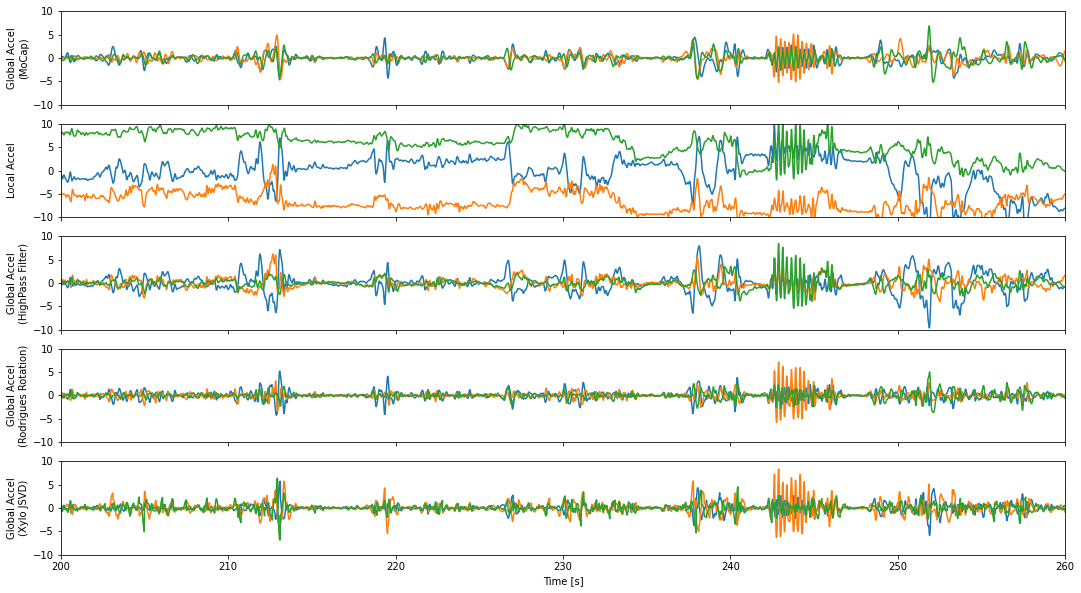

In [56]:
fig, ax = plt.subplots(5, 1, figsize=(18,10), sharex=True, sharey=True)

for d in range(3):
    sn.lineplot(x=timeMoCap, y=leftAccMoCap[:,d], ax=ax[0])
    sn.lineplot(x=timeLeftAcc, y=leftAcc[:,d], ax=ax[1])
    sn.lineplot(x=timeLeftAcc, y=leftGAccHPF[:,d], ax=ax[2])
    sn.lineplot(x=timeLeftAcc, y=leftGAccGC[:,d], ax=ax[3])
    sn.lineplot(x=timeLeftAcc, y=leftGAccXylo[:,d], ax=ax[4])

ax[0].set_xlim(200, 260)
ax[0].set_ylim(-10, 10)
ax[0].set_ylabel('Global Accel\n(MoCap)')
ax[1].set_ylabel('Local Accel\n ')
ax[2].set_ylabel('Global Accel\n(HighPass Filter)')
ax[3].set_ylabel('Global Accel\n(Rodrigues Rotation)')
ax[4].set_ylabel('Global Accel\n(Xylo JSVD)')
ax[-1].set_xlabel('Time [s]')

Metrics

In [57]:
T = len(timeLeftAcc)
NRMSE1 = np.sqrt(((leftAccMoCap[:T] - leftGAccHPF) ** 2).mean()) / 10
NRMSE2 = np.sqrt(((leftAccMoCap[:T] - leftGAccGC) ** 2).mean()) / 10
NRMSE3 = np.sqrt(((leftAccMoCap[:T] - leftGAccXylo) ** 2).mean()) / 10
SNR1 = np.sqrt((leftAccMoCap[:T] ** 2).mean()) / np.sqrt(((leftAccMoCap[:T] - leftGAccHPF) ** 2).mean())
SNR2 = np.sqrt((leftAccMoCap[:T] ** 2).mean()) / np.sqrt(((leftAccMoCap[:T] - leftGAccGC) ** 2).mean())
SNR3 = np.sqrt((leftAccMoCap[:T] ** 2).mean()) / np.sqrt(((leftAccMoCap[:T] - leftGAccXylo) ** 2).mean())

print(NRMSE1*100)
print(NRMSE2*100)
print(NRMSE3*100)
print(10*np.log10(SNR1))
print(10*np.log10(SNR2))
print(10*np.log10(SNR3))

15.495902994538705
10.90092913700896
12.474611522473653
-2.0039618674818254
-0.47642814204733513
-1.0620632768803013


Metrics per axis

In [58]:
T = len(timeLeftAcc)
NRMSE1 = np.sqrt(((leftAccMoCap[:T] - leftGAccHPF) ** 2).mean(0)) / 10
NRMSE2 = np.sqrt(((leftAccMoCap[:T] - leftGAccGC) ** 2).mean(0)) / 10
NRMSE3 = np.sqrt(((leftAccMoCap[:T] - leftGAccXylo) ** 2).mean(0)) / 10
SNR1 = np.sqrt((leftAccMoCap[:T] ** 2).mean(0)) / np.sqrt(((leftAccMoCap[:T] - leftGAccHPF) ** 2).mean(0))
SNR2 = np.sqrt((leftAccMoCap[:T] ** 2).mean(0)) / np.sqrt(((leftAccMoCap[:T] - leftGAccGC) ** 2).mean(0))
SNR3 = np.sqrt((leftAccMoCap[:T] ** 2).mean(0)) / np.sqrt(((leftAccMoCap[:T] - leftGAccXylo) ** 2).mean(0))

print(NRMSE1*100)
print(NRMSE2*100)
print(NRMSE3*100)
print(10*np.log10(SNR1))
print(10*np.log10(SNR2))
print(10*np.log10(SNR3))

[20.53232399 12.38222416 12.06122819]
[14.49563201 10.41903039  6.14908338]
[13.69218308 12.71558491 10.84830958]
[-2.53840449 -1.51307938 -1.32842263]
[-1.02639495 -0.76336581  1.59738889]
[-0.77875038 -1.62845619 -0.868128  ]
